<a href="https://colab.research.google.com/github/estebanurrutia1/Analitica/blob/main/Tarea_abril6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Librerías para la carga y visualización de las características de los datos**

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Librerías para etapa de preprocesamiento y transformación de las reseñas**

In [106]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Librerías para el modelamiento de los datos**

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

**Librerías para evaluacion del modelo**

In [108]:
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [109]:
"""

Se carga la base de datos. Hay que tener cuidado con la ruta o ubicación
del archivo. Para el presente caso se cargó directamente en Colab

"""

df = pd.read_csv("amazon_reviews.csv")

In [110]:
# Se revisa la estructura del archivo

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB


In [111]:
# Se revisan las primeras filas del archivo para darse una idea de qué contiene

df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [112]:
# Se revisa si hay valores nulos en las variables

df.isnull().sum()

,0
Unnamed: 0,0
reviewerName,1
overall,0
reviewText,1
reviewTime,0
day_diff,0
helpful_yes,0
helpful_no,0
total_vote,0
score_pos_neg_diff,0


In [113]:
# Se revisa la variable reviewText para analizar el tratamiento que requiere posrteriormente

df['reviewText'].head()

,reviewText
0,No issues.
1,"Purchased this for my device, it worked as adv..."
2,it works as expected. I should have sprung for...
3,This think has worked out great.Had a diff. br...
4,"Bought it with Retail Packaging, arrived legit..."


In [114]:
# Se rewvisa la distribución de las calificaciones de los clientes

df['overall'].value_counts()

,count
overall,
5.0,3922
4.0,527
1.0,244
3.0,142
2.0,80


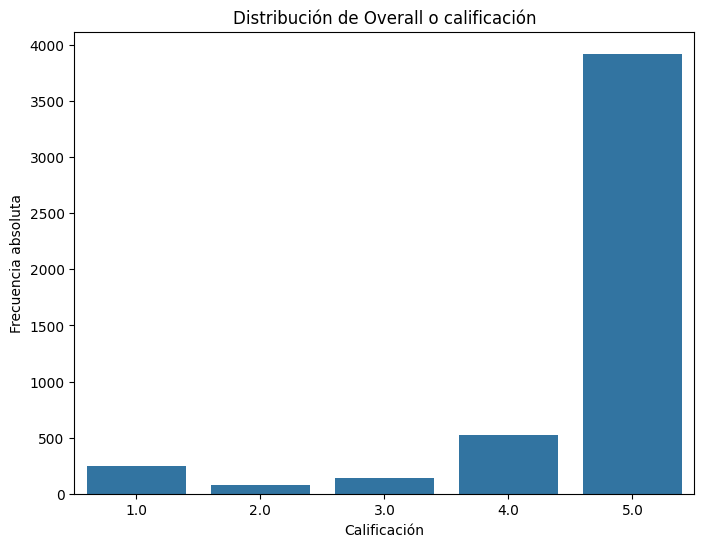

In [115]:
# Visualización de la distribución de las calificaciones de los clientes en la columna overall

plt.figure(figsize=(8, 6))
sns.countplot(x='overall', data=df)
plt.title('Distribución de Overall o calificación')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia absoluta')
plt.show()

In [116]:
# Se observa cómo son las reseñas y la calificación dada por el cliente

df[['reviewText', 'overall']].head()

,reviewText,overall
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


In [117]:
# Se realiza el Preprocesamiento, tokenizando y lematizando la variable reviewText

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if isinstance(text, str):
        tokens = word_tokenize(text.lower())
        tokens = [word for word in tokens if word.isalpha()]
        tokens = [word for word in tokens if word not in stop_words]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return " ".join(tokens)
    return ""

df['clean_text'] = df['reviewText'].apply(preprocess_text)

# Se eliminan las filas donde hay textos vacíos

df = df[df['clean_text'].str.strip() != ""].copy()

In [131]:
# Para ilustración, las stopwords se muestran a continuación

stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [119]:
# Se muestran ejemplos del texto transformado

df[['reviewText', 'clean_text']].head()

,reviewText,clean_text
0,No issues.,issue
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...
2,it works as expected. I should have sprung for...,work expected sprung higher capacity think mad...
3,This think has worked out great.Had a diff. br...,think worked diff bran card went south one hel...
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...


**Nota**

Las reseñas de Amazon vienen rankeadas de 1 a 5. La categoría negativa se da cuando el rating proporcionado por el usuario es igual o menor que 3 y positiva si es igual o mayor a 4. Se utiliza la siguiente línea de código:

In [120]:
# Se organizan las Etiquetas o calificaciones en dos categorias

df['label'] = df['overall'].apply(lambda x: 1 if x >= 4 else 0)

In [121]:
# Se organizan las Variables con las que se va a trabajar el modelamiento

X = df['clean_text']
y = df['label']

In [122]:
#  Se observa los valores de la nueva variable para terner claridad de qué se trata

y.head()

,label
0,1
1,1
2,1
3,1
4,1


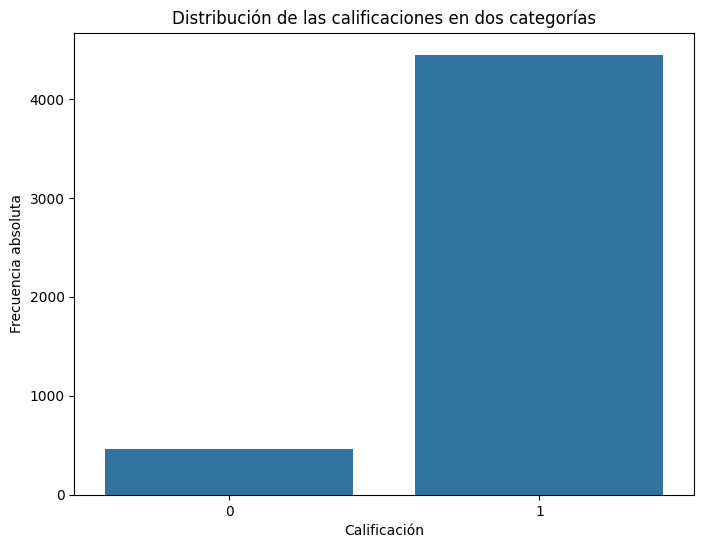

In [123]:
# Visualización de la distribución del sentimiento en la columna overall

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribución de las calificaciones en dos categorías')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia absoluta')
plt.show()

In [124]:
# Se realiza el Balanceo

oversampler = RandomOverSampler(random_state=42)
X_balanced, y_balanced = oversampler.fit_resample(X.to_frame(), y)
X_balanced = X_balanced['clean_text']

In [125]:
# Se entrena el modelo

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

In [126]:
# Se aplica la técnica de TF-IDF

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [127]:
# Se aplica una regresión logística al Modelo

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

**Nota:**


Para el análisis, coviene recodar que las reseñas de Amazon vienen rankeadas de 1 a 5. La categoría negativa se da cuando el rating proporcionado por el usuario es igual o menor que 3 y positiva si es igual o mayor a 4.

In [128]:
# Se evalua el modelo

y_pred = model.predict(X_test_tfidf)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))




Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       876
           1       0.97      0.93      0.95       903

    accuracy                           0.95      1779
   macro avg       0.95      0.95      0.95      1779
weighted avg       0.95      0.95      0.95      1779



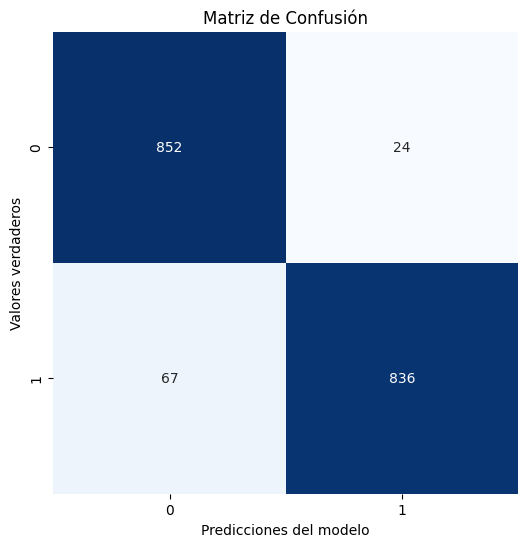

In [129]:
# Se realiza una Matriz de Confusión, para analizar visualmente los falsos positivos y falsos negativos

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones del modelo')
plt.ylabel('Valores verdaderos')
plt.title('Matriz de Confusión')
plt.show()

**Como conclusiones se tiene:**

1. Un Pipeline es un paso a paso que permite importar, describir, limpiar, organizar, tokenizar, lematizar, modelar y evaluar un modelo, para establecer la tasa de aciertos y desaciertos del entrenamiento del modelo.

2. Es importante tener claridad de qué recurso usar, lo cual depende de la actividad que se quiera realizar, e inclusive del tipo de datos a manejar.

3. Un factor clave es ir construyendo el modelo, entendiendo cada uno de los pasos y visualizando el resultado que éstos producen.

4. Realizar Pipeline, es una actividad que implica tiempo, análisis y reflexión, no solo de la construcción de código, sino del comportamiento y resultados.

5. Los resultados del modelo de análisis indican un rendimiento con una precisión entre el 93 % y 97 %.

6. Ambas puntuaciones (positivas y negativas), obtuvieron un valor de exactitud del 95 %